# Import the necessary libraries

In [1]:
import numpy as np
import pandas as pd

# Load the dataset

In [2]:
df = pd.read_csv('dataset/diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
# Replace zeros with null values
df.loc[df['Glucose'] == 0, 'Glucose'] = np.nan
df.loc[df['BloodPressure'] == 0, 'BloodPressure'] = np.nan
df.loc[df['SkinThickness'] == 0, 'SkinThickness'] = np.nan
df.loc[df['Insulin'] == 0, 'Insulin'] = np.nan
df.loc[df['BMI'] == 0, 'BMI'] = np.nan

In [4]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [5]:
mean_glucose = (df['Glucose']).mean()
mean_BloodPressure = (df['BloodPressure']).mean()
mean_SkinThickness = (df['SkinThickness']).mean()
mean_Insulin = (df['Insulin']).mean()
mean_BMI = (df['BMI']).mean()

In [6]:
df.fillna(
    {
        'Glucose': mean_glucose,
        'BloodPressure': mean_BloodPressure,
        'SkinThickness': mean_SkinThickness,
        'Insulin': mean_Insulin,
        'BMI': mean_BMI
    },
    inplace=True
)

In [7]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.00000,155.548223,33.6,0.627,50,1
1,1,85.0,66.0,29.00000,155.548223,26.6,0.351,31,0
2,8,183.0,64.0,29.15342,155.548223,23.3,0.672,32,1
3,1,89.0,66.0,23.00000,94.000000,28.1,0.167,21,0
4,0,137.0,40.0,35.00000,168.000000,43.1,2.288,33,1


# Separate features (X) and target (y)

In [8]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Split the data into training and testing sets

In [9]:
from sklearn.model_selection import train_test_split 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the data

In [10]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Initialize the logistic regression model with increased max_iter

In [12]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=200)

# Train the model

In [13]:
model.fit(X_train, y_train)

LogisticRegression(max_iter=200)

# Make predictions on the testing data

In [14]:
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, y_pred))
accuracy_score(y_train, model.predict(X_train))

0.7532467532467533


0.7719869706840391

# Cross-validation (using StratifiedKFold to maintain the distribution of classes)

In [15]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
cv = StratifiedKFold(n_splits=5)
cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc')
print(cv_scores)
print("Accuracy: {:2f}".format(cv_scores.mean()))
print("Standard Deviation: {:2f}".format(cv_scores.std()))

[0.7989418  0.86104651 0.83197674 0.83372093 0.84672619]
Accuracy: 0.834482
Standard Deviation: 0.020618


# Plot the confusion matrix

[[82 17]
 [21 34]]


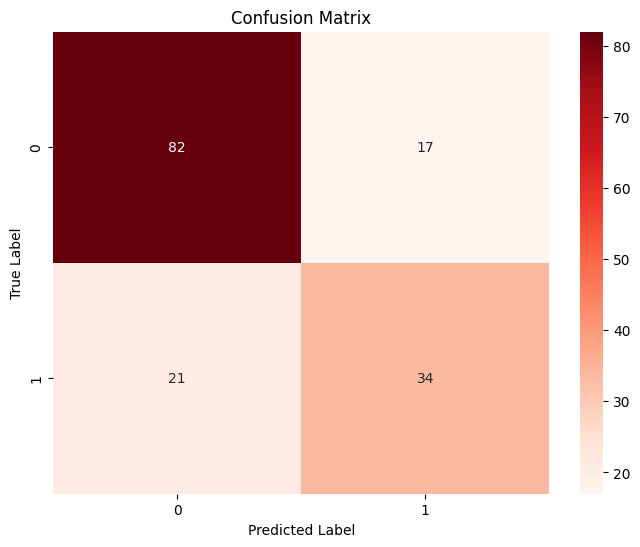

In [17]:
from sklearn.metrics import roc_auc_score, f1_score, roc_curve, confusion_matrix, classification_report
conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Reds')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# AUC and ROC Curve

In [33]:
from sklearn.metrics import roc_auc_score, f1_score, roc_curve, confusion_matrix, classification_report, recall_score, precision_score
auc = roc_auc_score(y_test, y_pred_prob)
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
class_report = classification_report(y_test, y_pred)
print(class_report)

ValueError: Found input variables with inconsistent numbers of samples: [154, 614]

# F1 Score

In [19]:
f1 = f1_score(y_test, y_pred)
f1

0.6415094339622641

# ROC Curve

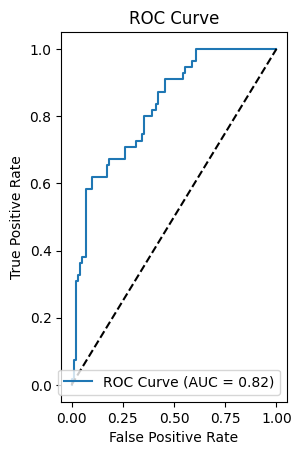

In [20]:
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')

# Evaluate the model

In [21]:
print(f'Cross-Validation AUC Scores: {cv_scores}')
print(f'Mean Cross-Validation AUC: {np.mean(cv_scores):.2f}')
print(f'F1 Score: {f1:.2f}')
print(f'Classification Report:\n{class_report}')

Cross-Validation AUC Scores: [0.7989418  0.86104651 0.83197674 0.83372093 0.84672619]
Mean Cross-Validation AUC: 0.83
F1 Score: 0.64
Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.83      0.81        99
           1       0.67      0.62      0.64        55

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.73       154
weighted avg       0.75      0.75      0.75       154



In [26]:
import torch
import torch.nn as nn
import torch.optim as optim

In [31]:
y_train.values

array([0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0,
       1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1,
       0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0,
       1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0,

In [37]:
# Convert data to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train)
X_test_tensor = torch.FloatTensor(X_test)
y_train_tensor = torch.FloatTensor(y_train.values).reshape(-1, 1)
y_test_tensor = torch.FloatTensor(y_test.values).reshape(-1, 1)

# Define the neural network
class DiabetesPredictor(nn.Module):
    def __init__(self, input_features):
        super().__init__()
        self.layer1 = nn.Linear(input_features, 64)
        self.layer2 = nn.Linear(64, 32)
        self.output = nn.Linear(32, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.sigmoid(self.output(x))
        return x

# Initialize model
model = DiabetesPredictor(X_train.shape[1])

# Loss and optimizer
criterion = nn.BCELoss()  # Binary Cross Entropy Loss
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
epochs = 1000
for epoch in range(epochs):
    # Forward pass
    y_pred = model(X_train_tensor)
    loss = criterion(y_pred, y_train_tensor)
    
    # Backward pass and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if (epoch+1) % 100 == 0:
        print(f'Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}')

# Evaluation
with torch.inference_mode():
    test_pred = model(X_test_tensor)
    test_pred_classes = torch.round(test_pred)
    
    # Convert to numpy for sklearn metrics
    y_test_np = y_test_tensor.numpy().flatten()
    test_pred_np = test_pred_classes.numpy().flatten()
    
    # Calculate metrics
    accuracy = accuracy_score(y_test_np, test_pred_np)
    precision = precision_score(y_test_np, test_pred_np)
    recall = recall_score(y_test_np, test_pred_np)
    f1 = f1_score(y_test_np, test_pred_np)
    conf_matrix = confusion_matrix(y_test_np, test_pred_np)
    
    print("\nEvaluation Metrics:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print("Confusion Matrix:")
    print(conf_matrix)

# Prediction example
with torch.inference_mode():
    sample_idx = 0
    sample_data = X_test_tensor[sample_idx]
    prediction = model(sample_data)
    print(f"\nSample prediction: {prediction.item():.4f} | Actual: {y_test_np[sample_idx]}")

Epoch 100/1000, Loss: 0.4185
Epoch 200/1000, Loss: 0.3566
Epoch 300/1000, Loss: 0.2850
Epoch 400/1000, Loss: 0.1950
Epoch 500/1000, Loss: 0.1186
Epoch 600/1000, Loss: 0.0646
Epoch 700/1000, Loss: 0.0358
Epoch 800/1000, Loss: 0.0208
Epoch 900/1000, Loss: 0.0131
Epoch 1000/1000, Loss: 0.0088

Evaluation Metrics:
Accuracy: 0.6883
Precision: 0.5574
Recall: 0.6182
F1 Score: 0.5862
Confusion Matrix:
[[72 27]
 [21 34]]

Sample prediction: 0.9999 | Actual: 0.0


# Function to take user input and make a prediction

In [22]:
def get_user_input_and_predict():
    print("Please enter the following details to check if you are diabetic or not:")
    Pregnancies = float(input("Number of Pregnancies: "))
    Glucose = float(input("Glucose Level: "))
    BloodPressure = float(input("Blood Pressure: "))
    SkinThickness = float(input("Skin Thickness: "))
    Insulin = float(input("Insulin Level: "))
    BMI = float(input("BMI: "))
    DiabetesPedigreeFunction = float(input("Diabetes Pedigree Function: "))
    Age = float(input("Age: "))
    
    user_data = pd.DataFrame({
        'Pregnancies': [Pregnancies],
        'Glucose': [Glucose],
        'BloodPressure': [BloodPressure],
        'SkinThickness': [SkinThickness],
        'Insulin': [Insulin],
        'BMI': [BMI],
        'DiabetesPedigreeFunction': [DiabetesPedigreeFunction],
        'Age': [Age]
    })
    
    user_data_scaled = scaler.transform(user_data)
    
    prediction = model.predict(user_data_scaled)
    probability = model.predict_proba(user_data_scaled)

    if prediction[0] == 1:
        print("Based on the input values, you are predicted to be diabetic.")
    else:
        print("Based on the input values, you are predicted to not be diabetic.")
    
    print(f"Probability of being diabetic: {probability[0][1]:.2f}")
    print(f"Probability of not being diabetic: {probability[0][0]:.2f}")

# Get user input and make prediction

In [23]:
get_user_input_and_predict()

Please enter the following details to check if you are diabetic or not:


Number of Pregnancies:  0
Glucose Level:  100
Blood Pressure:  80
Skin Thickness:  3
Insulin Level:  78
BMI:  28
Diabetes Pedigree Function:  2
Age:  28


Based on the input values, you are predicted to not be diabetic.
Probability of being diabetic: 0.14
Probability of not being diabetic: 0.86


Number of Pregnancies:  2
Glucose Level:  0
Blood Pressure:  0
Skin Thickness:  0
Insulin Level:  0
BMI:  0
Diabetes Pedigree Function:  1
Age:  21


Based on the input values, you are predicted to not be diabetic.
Probability of being diabetic: 0.00
Probability of not being diabetic: 1.00


# Export the model

In [8]:
import joblib
#export model and scaler
export_dict = {'model': model, 'scaler': scaler}
# Save to a single .pkl file
joblib.dump(export_dict, 'model_and_scaler.pkl')

ModuleNotFoundError: No module named 'joblib'